In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_dir = "../dataset/raw/Training"
test_dir = "../dataset/raw/Testing"

Configuration

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

Create Training Generator

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    validation_split=0.20,

    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

Create Validation Generator

In [5]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

Training Dataset

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

Found 4571 images belonging to 4 classes.


Validation Dataset

In [7]:
validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=SEED
)

Found 1141 images belonging to 4 classes.


Testing Dataset

In [8]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1272 images belonging to 4 classes.


Verify Classes

In [9]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [10]:
x_batch, y_batch = next(train_generator)

print("Image Batch Shape:", x_batch.shape)
print("Label Batch Shape:", y_batch.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 4)


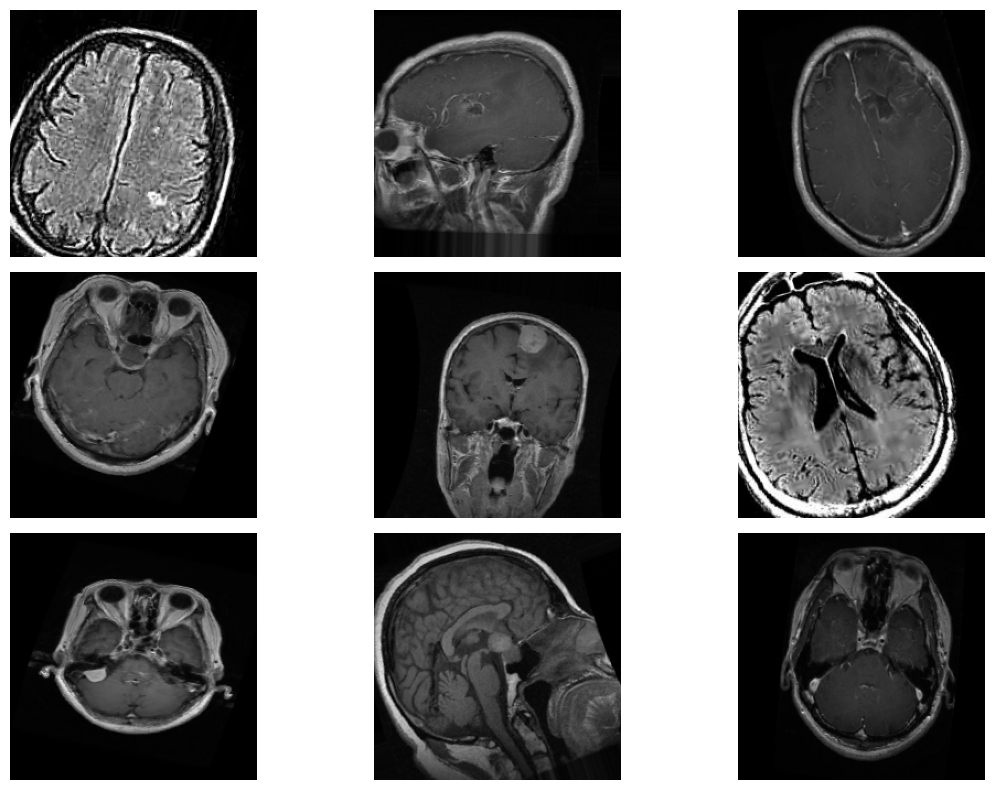

In [11]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(x_batch[i])

    plt.axis("off")

plt.tight_layout()
plt.show()